In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/content/Unemployment in India.csv")

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
LE = LabelEncoder()

In [7]:
df['Region'] = LE.fit_transform(df['Region'])
df[' Date'] = LE.fit_transform(df[' Date'])
df[' Frequency'] = LE.fit_transform(df[' Frequency'])
df['Area'] = LE.fit_transform(df['Area'])

In [8]:
SS = StandardScaler()

In [9]:
df[' Estimated Employed'] = SS.fit_transform(df[[' Estimated Employed']])

In [10]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,0,8,0,3.65,0.593216,43.24,0
1,0,2,0,3.05,0.563119,42.05,0
2,0,10,0,3.75,0.604050,43.50,0
3,0,11,0,3.32,0.628669,43.97,0
4,0,4,0,5.17,0.625090,44.68,0


In [11]:
df.describe()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,768.000000,768.000000,768.000000,740.000000,7.400000e+02,740.000000,768.000000
mean,14.212240,6.808594,0.569010,11.787946,-3.840772e-17,42.630122,0.569010
std,8.347443,4.202015,0.564419,10.721298,1.000676e+00,8.111094,0.564419
min,0.000000,0.000000,0.000000,0.000000,-8.852485e-01,13.330000,0.000000
25%,7.000000,3.000000,0.000000,4.657500,-7.440816e-01,38.062500,0.000000
50%,14.000000,7.000000,1.000000,8.350000,-3.043953e-01,41.160000,1.000000
75%,22.000000,10.000000,1.000000,15.887500,5.036831e-01,45.505000,1.000000
max,28.000000,14.000000,2.000000,76.740000,4.772403e+00,72.570000,2.000000


In [12]:
df.shape

(768, 7)

In [13]:
df['Region'].value_counts()

,count
Region,
0,28
2,28
4,28
5,28
7,28
13,28
8,28
9,28
11,28


In [14]:
df['Area'].value_counts()

,count
Area,
1,381
0,359
2,28


In [15]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,0


In [16]:
df[' Estimated Unemployment Rate (%)'] = df[' Estimated Unemployment Rate (%)'].fillna(df[' Estimated Unemployment Rate (%)'].mean())
df[' Estimated Employed'] = df[' Estimated Employed'].fillna(df[' Estimated Employed'].mean())
df[' Estimated Labour Participation Rate (%)'] = df[' Estimated Labour Participation Rate (%)'].fillna(df[' Estimated Labour Participation Rate (%)'].mean())

In [17]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [18]:
X = df.drop(columns=[' Estimated Employed'],axis=1)
Y = df[' Estimated Employed']

In [19]:
X.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Area
0,0,8,0,3.65,43.24,0
1,0,2,0,3.05,42.05,0
2,0,10,0,3.75,43.50,0
3,0,11,0,3.32,43.97,0
4,0,4,0,5.17,44.68,0


In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train,Y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [25]:
r2

0.1502018012581574

In [26]:
mse

0.9173591797530909

In [27]:
input = [[0,4,0,5.17,44.68,0]]

In [28]:
UnEmp_pred = model.predict(input)

In [29]:
print("Unemployment Prediction in %:",UnEmp_pred[0])

Unemployment Prediction in %: 0.0020102784865935197


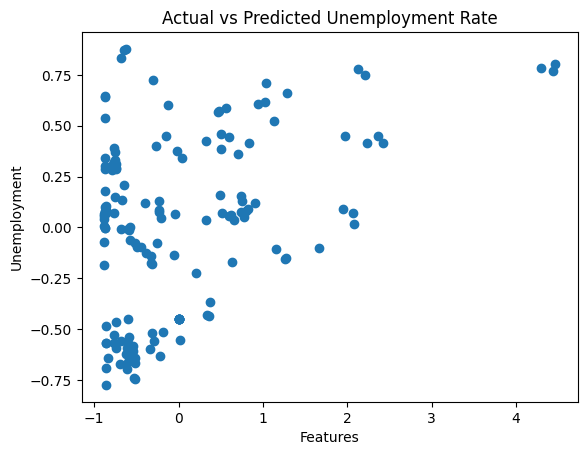

In [30]:
plt.scatter(Y_test,y_pred)
plt.xlabel("Features")
plt.ylabel("Unemployment")
plt.title("Actual vs Predicted Unemployment Rate")
plt.show()

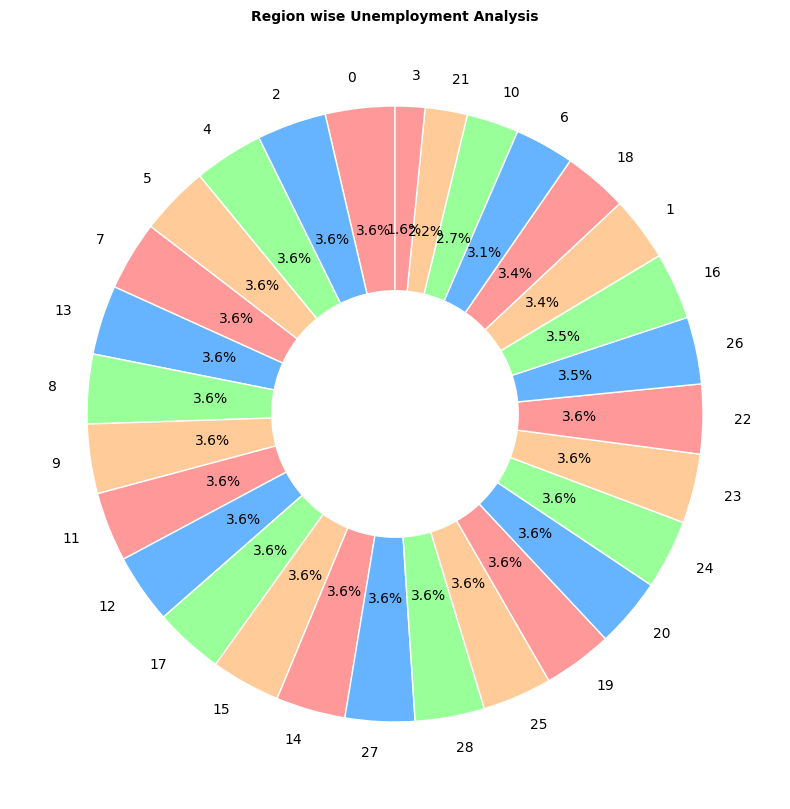

In [38]:
region_data = df['Region'].value_counts()
categories = region_data.index
sizes = region_data.values
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(sizes,labels=categories,autopct='%1.1f%%',startangle=90,colors=colors,wedgeprops=dict(width=0.6, edgecolor='white'))
ax.set_title("Region wise Unemployment Analysis", fontsize=10, fontweight='bold')
plt.show()